In [1]:
# !pip install "nemo_toolkit[asr]"

In [ ]:
import torch
import numpy as np
nemo.utils.logging.set_verbosity(nemo.utils.logging.ERROR)
import torchaudio
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from IPython.display import Audio, display
from omegaconf import OmegaConf

In [3]:
import nemo.collections.asr as nemo_asr

# 1. Carga los pesos del modelo (que están en 32 bits por defecto) directamente en la memoria RAM.
_CANARY_MODEL_1b_v2 = nemo_asr.models.ASRModel.from_pretrained("nvidia/canary-1b-v2")

#_CANARY_MODEL_1b_v2 = nemo_asr.models.ASRModel.from_pretrained("nvidia/canary-1b-v2", map_location="cpu")

# 2. Convierte todos los parámetros del modelo de 32 bits (float32) a 16 bits (float16).
#_CANARY_MODEL_1b_v2 = _CANARY_MODEL_1b_v2.bfloat16()

# 3. Mueve el modelo, que ahora pesa la mitad, a la memoria de la GPU.
#_CANARY_MODEL_1b_v2 = _CANARY_MODEL_1b_v2.to('cuda')


/home/garayco/master_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[NeMo W 2026-03-24 20:39:17 nemo_logging:405] Megatron num_microbatches_calculator not found, using Apex version.
OneLogger: Setting error_handling_strategy to DISABLE_QUIETLY_AND_REPORT_METRIC_ERROR for rank (rank=0) with OneLogger disabled. To override: explicitly set error_handling_strategy parameter.
No exporters were provided. This means that no telemetry data will be collected.


[NeMo I 2026-03-24 20:39:43 nemo_logging:393] Tokenizer CanaryBPETokenizer initialized with 16384 tokens


[NeMo W 2026-03-24 20:39:43 nemo_logging:405] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    use_lhotse: true
    skip_missing_manifest_entries: true
    input_cfg: null
    tarred_audio_filepaths: null
    manifest_filepath: null
    sample_rate: 16000
    shuffle: true
    num_workers: 4
    pin_memory: true
    prompt_format: canary2
    max_duration: 40.0
    min_duration: 0.01
    text_field: answer
    lang_field: target_lang
    use_bucketing: true
    max_tps: null
    bucket_duration_bins: null
    bucket_batch_size: null
    num_buckets: null
    bucket_buffer_size: 20000
    shuffle_buffer_size: 10000
    
[NeMo W 2026-03-24 20:39:43 nemo_logging:405] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the 

[NeMo I 2026-03-24 20:39:43 nemo_logging:393] PADDING: 0


Error getting class at nemo.collections.asr.modules.transformer.get_nemo_transformer: Located non-class of type 'function' while loading 'nemo.collections.asr.modules.transformer.get_nemo_transformer'


[NeMo I 2026-03-24 20:40:13 nemo_logging:393] Tokenizer SentencePieceTokenizer initialized with 16384 tokens


[NeMo W 2026-03-24 20:40:16 nemo_logging:405] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    use_lhotse: true
    skip_missing_manifest_entries: true
    input_cfg: null
    tarred_audio_filepaths: null
    manifest_filepath: null
    sample_rate: 16000
    shuffle: true
    num_workers: 2
    pin_memory: true
    max_duration: 40.0
    min_duration: 0.1
    text_field: answer
    batch_duration: null
    max_tps: null
    use_bucketing: true
    bucket_duration_bins: null
    bucket_batch_size: null
    num_buckets: null
    bucket_buffer_size: 20000
    shuffle_buffer_size: 10000
    
[NeMo W 2026-03-24 20:40:16 nemo_logging:405] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation data loader(s). 
   

[NeMo I 2026-03-24 20:40:16 nemo_logging:393] PADDING: 0
[NeMo I 2026-03-24 20:40:27 nemo_logging:393] Model EncDecCTCModelBPE was successfully restored from /home/garayco/.cache/huggingface/hub/models--nvidia--canary-1b-v2/snapshots/87bc52657add533cd0156b3fc1aef027280754bf/canary-1b-v2.nemo.
[NeMo I 2026-03-24 20:40:34 nemo_logging:393] Model EncDecMultiTaskModel was successfully restored from /home/garayco/.cache/huggingface/hub/models--nvidia--canary-1b-v2/snapshots/87bc52657add533cd0156b3fc1aef027280754bf/canary-1b-v2.nemo.


In [4]:
print(type(_CANARY_MODEL_1b_v2))

<class 'nemo.collections.asr.models.aed_multitask_models.EncDecMultiTaskModel'>


In [5]:
print(_CANARY_MODEL_1b_v2)

EncDecMultiTaskModel(
  (preprocessor): AudioToMelSpectrogramPreprocessor(
    (featurizer): FilterbankFeatures()
  )
  (encoder): ConformerEncoder(
    (pre_encode): ConvSubsampling(
      (out): Linear(in_features=4096, out_features=1024, bias=True)
      (conv): MaskedConvSequential(
        (0): Conv2d(1, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=256)
        (3): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
        (4): ReLU(inplace=True)
        (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=256)
        (6): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
        (7): ReLU(inplace=True)
      )
    )
    (pos_enc): RelPositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-31): 32 x ConformerLayer(
        (norm_feed_forward1): LayerNorm((1024,), eps=1e

In [6]:
audio_path = "Grabacion.m4a"

signal, sr = librosa.load(audio_path, sr=16000)

print("Sample rate original:", sr)
print("Shape original:", signal.shape)

Sample rate original: 16000
Shape original: (70998,)


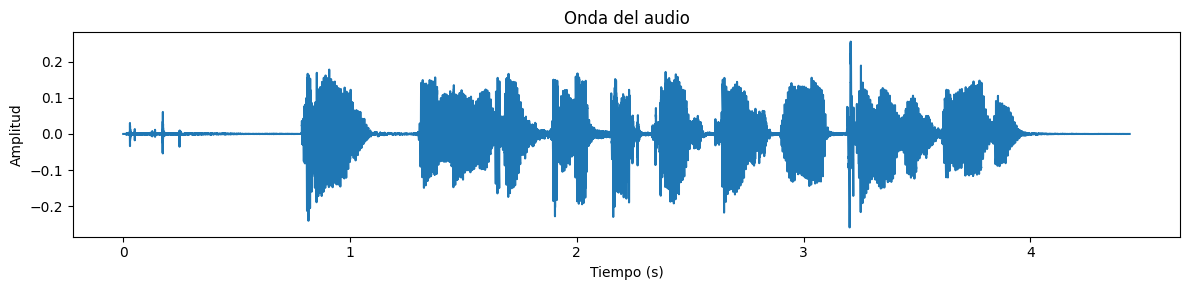

In [7]:
display(Audio(audio_path))
plt.figure(figsize=(12, 3))

time = torch.arange(len(signal)) / sr
plt.plot(time, signal)
plt.title("Onda del audio")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

plt.tight_layout()
plt.show()

## ETAPA 1: PREPROCESAMIENTO DEL AUDIO EN CANARY

In [8]:
print(_CANARY_MODEL_1b_v2.preprocessor)

AudioToMelSpectrogramPreprocessor(
  (featurizer): FilterbankFeatures()
)


In [9]:
print(OmegaConf.to_yaml(_CANARY_MODEL_1b_v2.cfg.preprocessor))

pre = _CANARY_MODEL_1b_v2.cfg.preprocessor

n_fft = pre["n_fft"]
hop_length = int(pre["window_stride"] * pre["sample_rate"])
win_length = int(pre["window_size"] * pre["sample_rate"])
n_mels = pre["features"]
window = pre["window"]

_target_: nemo.collections.asr.modules.AudioToMelSpectrogramPreprocessor
sample_rate: 16000
normalize: per_feature
window_size: 0.025
window_stride: 0.01
window: hann
features: 128
n_fft: 512
log: true
frame_splicing: 1
dither: 1.0e-05
pad_to: 0
pad_value: 0.0



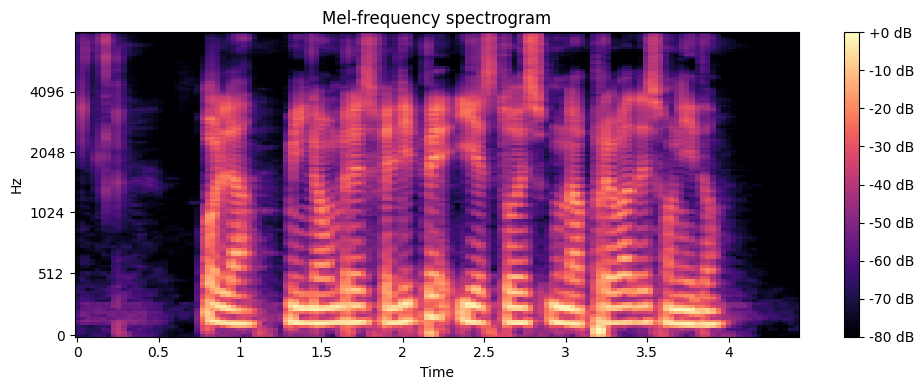

In [10]:
S = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=n_mels)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-frequency spectrogram')
plt.tight_layout()
plt.show()

### ¿ Como lo hace Canary ?

In [11]:
signal_tensor = torch.tensor(signal, dtype=torch.float32)

# 1. Crea el Extractor de Spectrogramas
mel_extractor = torchaudio.transforms.MelSpectrogram(
    sample_rate=sr,
    n_fft=n_fft,
    win_length=win_length,
    hop_length=hop_length,
    n_mels=n_mels,
    window_fn=torch.hann_window,
    mel_scale="slaney",
    norm="slaney"
)

mel_spec_ta = mel_extractor(signal_tensor)

print(f"Shape del tensor de audio original: {signal_tensor.shape}")
print(f"Shape del espectrograma base (torchaudio): {mel_spec_ta.shape}")
print(f"Valor máximo actual: {mel_spec_ta.max().item():.4f}")
print(f"Valor mínimo actual: {mel_spec_ta.min().item():.4f}")


Shape del tensor de audio original: torch.Size([70998])
Shape del espectrograma base (torchaudio): torch.Size([128, 444])
Valor máximo actual: 6.6106
Valor mínimo actual: 0.0000


In [12]:
# 2. Guardia de ceros: Evitar logaritmo de cero haciendo "clamp" en 1e-5
mel_spec_clamped = torch.clamp(mel_spec_ta, min=1e-5)
print(f"Nuevo valor mínimo después del clamp: {mel_spec_clamped.min().item():.5f}")

Nuevo valor mínimo después del clamp: 0.00001


In [13]:
# 3. Escala logarítmica: NeMo usa logaritmo natural puro (no power_to_db)
mel_spec_log = torch.log(mel_spec_clamped)
print(f"Rango de valores tras logaritmo: [{mel_spec_log.min().item():.4f} a {mel_spec_log.max().item():.4f}]")

Rango de valores tras logaritmo: [-11.5129 a 1.8887]


In [14]:
# 4. Normalización (Per-Feature): normalizamos cada banda de frecuencia para tener media 0 y varianza 1

# Calculamos la media y desviación estándar a lo largo del tiempo (dim=1) para cada uno de los 128 canales
mel_mean = mel_spec_log.mean(dim=1, keepdim=True)
mel_std = mel_spec_log.std(dim=1, keepdim=True)

# Aplicamos la normalización y sumamos 1e-5 a la desviación para evitar divisiones por cero
mel_spec_final = (mel_spec_log - mel_mean) / (mel_std + 1e-5)

print(f"Shape del tensor matemático final: {mel_spec_final.shape}")
print(f"Media global aproximada: {mel_spec_final.mean().item():.4f}")
print(f"Desviación estandar aproximada: {mel_spec_final.std().item():.4f}")
print(f"Rango final de valores normalizados: [{mel_spec_final.min().item():.4f} a {mel_spec_final.max().item():.4f}]")


Shape del tensor matemático final: torch.Size([128, 444])
Media global aproximada: -0.0000
Desviación estandar aproximada: 0.9989
Rango final de valores normalizados: [-1.3996 a 8.3643]


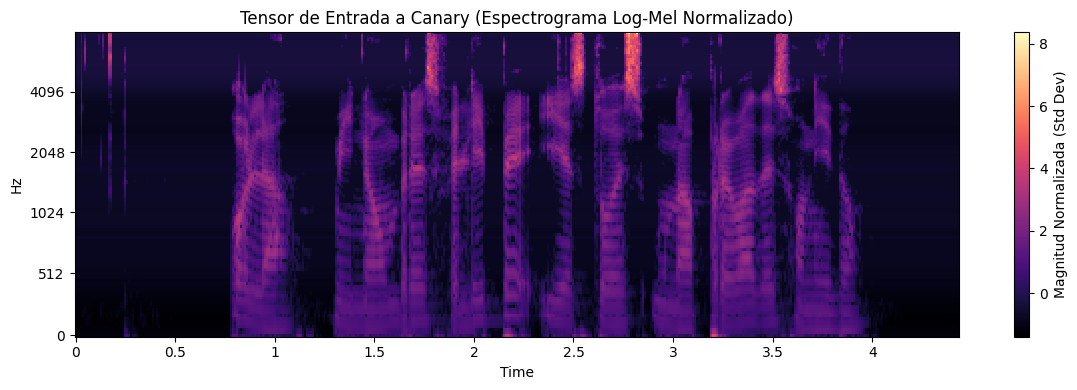

In [15]:
plt.figure(figsize=(12, 4))

librosa.display.specshow(
    mel_spec_final.numpy(), 
    sr=sr, 
    hop_length=hop_length, 
    x_axis="time", 
    y_axis="mel",
    cmap="magma" 
)

plt.colorbar(label='Magnitud Normalizada (Std Dev)')
plt.title("Tensor de Entrada a Canary (Espectrograma Log-Mel Normalizado)")
plt.tight_layout()
plt.show()


In [16]:
processed_signal = mel_spec_final

print("Representación final de preprocesamiento")
print("Dimensiones:", processed_signal.shape)
print("Interpretación:")
print("- Eje 0:", processed_signal.shape[0], "bandas mel / features")
print("- Eje 1:", processed_signal.shape[1], "pasos temporales")

Representación final de preprocesamiento
Dimensiones: torch.Size([128, 444])
Interpretación:
- Eje 0: 128 bandas mel / features
- Eje 1: 444 pasos temporales


## ETAPA 2: Encoder (FastConformer)


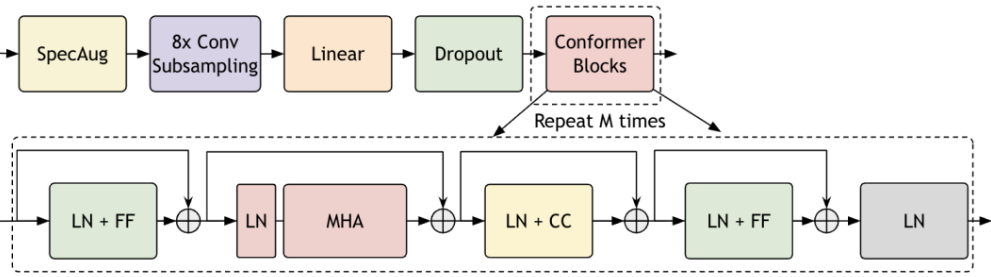

FastConformer es una evolución del codificador Conformer, optimizado específicamente para la eficiencia computacional en tareas de voz. Sus principales mejoras con respecto al Conformer original incluyen:

### **1. Aggressive Subsampling (8x):**

Las características de entrada se submuestrean por un factor de 8 en la etapa de entrada `(pre_encode): ConvSubsampling -> (conv): MaskedConvSequential` mediante bloques convolucionales. Esto acorta significativamente la longitud de la secuencia, reduciendo el coste computacional sin comprometer la precisión.

### **2. Depthwise Separable Convolutions:** 

Las convoluciones estándar tanto en las capas de submuestreo `(conv): MaskedConvSequential` como en los bloques Conformer `ConformerLayer -> (conv): ConformerConvolution` se reemplazan por convoluciones separables en profundidad, lo que reduce el número de operaciones manteniendo un alto rendimiento.

#### Ejemplo con 2 Capas de FastConformer `(pre_encode): ConvSubsampling -> (conv): MaskedConvSequential`

```python
(2): Conv2d(256, 256, kernel_size=(3,3), stride=2, padding=1, groups=256)
(3): Conv2d(256, 256, kernel_size=(1,1))
```

##### Depthwise Convolution
```python
Conv2d(..., kernel=(3,3), stride=2, groups=256)
```

- Cada uno de los 256 canales se procesa por separado
- Se aplica un filtro 3×3 por canal
- NO hay mezcla entre canales
- stride=2 reduce la resolución (downsampling)

##### Pointwise Convolution
```python
Conv2d(..., kernel=(1,1))
```
- Mezcla la información entre los 256 canales
- Cada salida es una combinación de todos los canales

**¿Por qué es mas rapido?**
*(Operaciones para una sola posición espacial)*
- **Conv Convencional:** Empareja cada píxel contra cada canal de entrada y salida simultáneamente.
  `3 × 3 × 256 × 256 = 589,824` multiplicaciones.
- **La Solución Separable:**
  1. *Depthwise:* Aprende patrones espaciales por canal sin cruzarlos (`groups=256`). `3 × 3 × 256 = 2,304` multiplicaciones.
  2. *Pointwise:* Combina o mezcla los resultados de esos patrones usando un núcleo de 1x1 `1 × 1 × 256 × 256 = 65,536` multiplicaciones. **Totales:** `67,840`.

### **3. Lightweight Convolutional Modules:** 

Estos módulos son versiones optimizadas del bloque convolucional Conformer. Mientras que el diseño original utilizaba kernels extensos (de 31 o 32) para capturar contexto temporal, esta arquitectura reduce su tamaño a 9 (`(conv): ConformerConvolution -> (depthwise_conv): CausalConv1D `), eliminando redundancias con el mecanismo de self-attention que ya gestiona eficazmente las dependencias globales. Esta eficiencia se potencia mediante el uso de convoluciones de profundidad separable (Depthwise Separable). Así, la convolución se especializa exclusivamente en la extracción de patrones acústicos locales, mientras que la modelación de relaciones temporales complejas recae íntegramente en el sistema de atención. 

Añadir que tambien usualmente se hace subsampling de 4x y fastconformer lo hace de 8x




In [17]:
print(_CANARY_MODEL_1b_v2.encoder)

ConformerEncoder(
  (pre_encode): ConvSubsampling(
    (out): Linear(in_features=4096, out_features=1024, bias=True)
    (conv): MaskedConvSequential(
      (0): Conv2d(1, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=256)
      (3): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
      (4): ReLU(inplace=True)
      (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=256)
      (6): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
      (7): ReLU(inplace=True)
    )
  )
  (pos_enc): RelPositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (layers): ModuleList(
    (0-31): 32 x ConformerLayer(
      (norm_feed_forward1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (feed_forward1): ConformerFeedForward(
        (linear1): Linear(in_features=1024, out_features=4096, bias=True)
        (activation)

In [18]:
print(OmegaConf.to_yaml(_CANARY_MODEL_1b_v2.cfg.encoder))

_target_: nemo.collections.asr.modules.ConformerEncoder
feat_in: 128
feat_out: -1
n_layers: 32
d_model: 1024
subsampling: dw_striding
subsampling_factor: 8
subsampling_conv_channels: 256
causal_downsampling: false
reduction: null
reduction_position: null
reduction_factor: 1
ff_expansion_factor: 4
self_attention_model: rel_pos
n_heads: 8
att_context_size:
- -1
- -1
xscaling: false
untie_biases: true
pos_emb_max_len: 5000
conv_kernel_size: 9
conv_norm_type: batch_norm
conv_context_size: null
dropout: 0.1
dropout_pre_encoder: 0.1
dropout_emb: 0.0
dropout_att: 0.1



In [19]:
processed_signal.shape

torch.Size([128, 444])

### **Aggressive Subsampling (8x)** `MaskedConvSequential`

subsampling_factor=8 crea las 3 conv2d que reduce 3 veces a la mitad el tiempo (stride = 2)

El framework lee el factor `8` de la configuración. Al tomar su logaritmo base 2, se da cuenta de que necesita **colocar 3 capas convolucionales encadenadas**, cada una con la capacidad de reducir el tiempo a la mitad (`stride = 2`).
- Capa 1: Reduce los $444$ a la mitad $\approx 222$.
- Capa 2: Reduce los $222$ a la mitad $\approx 111$.
- Capa 3: Reduce los $111$ a la mitad $\approx 56$.

In [20]:
# 1. Extraemos el módulo de subsampling del encoder y averiguamos su dispositivo
conv_subsampling = _CANARY_MODEL_1b_v2.encoder.pre_encode
# Ponemos el módulo en modo evaluación (para evitar dropouts si los hubiera)
conv_subsampling.eval()
conv_subsampling

ConvSubsampling(
  (out): Linear(in_features=4096, out_features=1024, bias=True)
  (conv): MaskedConvSequential(
    (0): Conv2d(1, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=256)
    (3): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (4): ReLU(inplace=True)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=256)
    (6): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (7): ReLU(inplace=True)
  )
)

In [21]:
device = next(_CANARY_MODEL_1b_v2.parameters()).device
device

device(type='cuda', index=0)

In [22]:
# 2. Preparar el tensor de entrada
# 'processed_signal' tiene forma [128, T]. 

# ConvSubsampling espera la forma [Batch, Time, Features]
x_input = processed_signal.unsqueeze(0)   # Añade Batch: [1, 128, T]
x_input = x_input.transpose(1, 2)         # Transpone a: [1, T, 128]

# 3. Preparar el tensor de longitudes (requerido por la función forward del subsampling)
lengths = torch.tensor([processed_signal.shape[1]], dtype=torch.int64)

# Enviar tensores al mismo dispositivo (GPU) que el modelo 
x_input = x_input.to(device)
lengths = lengths.to(device)

In [23]:
# 4. Procesar la señal a través del ConvSubsampling
with torch.no_grad():
    x_subsampled, new_lengths = conv_subsampling(x=x_input, lengths=lengths)

# 5. Ilustrar la transformación
print(f"1. Forma de entrada al Subsampling : {x_input.shape}  -> [Batch, Time_Original, Features_Mels]")
print(f"2. Forma de salida del Subsampling : {x_subsampled.shape}  -> [Batch, Time_Reducido, d_model]")
print(f"3. Pasos de tiempo originales      : {lengths.item()}")
print(f"4. Pasos de tiempo tras reducción  : {new_lengths.item()}")


1. Forma de entrada al Subsampling : torch.Size([1, 444, 128])  -> [Batch, Time_Original, Features_Mels]
2. Forma de salida del Subsampling : torch.Size([1, 56, 1024])  -> [Batch, Time_Reducido, d_model]
3. Pasos de tiempo originales      : 444
4. Pasos de tiempo tras reducción  : 56


¡Este output es oro puro para tu sustentación! Acabas de revelar una de las decisiones arquitectónicas más importantes que tomaron los investigadores de Nvidia al diseñar **Canary-1B**.

Traduciendo lo que ves en pantalla al contexto de tu trabajo, esto es lo que ocurrió paso a paso con los tensores matemáticos:

#### 1. La Reducción Extrema de Tiempo (Time Reduction)
- **De dónde venimos:** Tu audio original tiene `444` cuadros (frames) temporales. Teniendo en cuenta el "paso" (*hop length*) de 10ms, `444` equivale a unos 4.4 segundos de audio.
- **Lo que pasó:** El tensor cruzó por una serie de capas convolucionales 2D (*Conv2d*) configuradas con saltos (*strides*). Fíjate en la matemática: $444 / 8 = 55.5$ (que con el redondeo o el *padding* de las orillas resultó exactamente en `56`). 
- **La Revelación (Innovación):** ¡Canary utiliza un **factor de submuestreo de 8x (`subsampling_factor=8`)**! La mayoría de los modelos Conformer estándar reducen el tiempo a un cuarto ($4\times$), pero Canary, al ser un modelo masivo de 1 billón de parámetros, colapsaría la memoria de casi cualquier GPU si mantuviera la secuencia larga. 
- **¿Por qué esto es brillante?** El mecanismo de atención pura de un Transformer crece de forma cuadrática $O(T^2)$. Al obligar a la secuencia a encogerse de $444$ a $56$, reducen la carga computacional de la Atención en un factor de $64$ veces, combinando y aplastando la acústica de cada 80 milisegundos de habla en un solo bloque sólido.

#### 2. La Expansión Dimensional (`d_model`)
- **De dónde venimos:** El espectrograma Mel solo tiene `128` bandas o "canales de frecuencia". Era algo visual.
- **Lo que pasó:** Los filtros de las capas convolucionales operaron sobre el espectrograma como si fuera una imagen, extrayendo patrones, texturas, formas de formantes vocales y características complejas de la voz.
- **La Proyección:** Una vez "masticada" esa imagen acústica, se expandió y convirtió en vectores abstractos profundos de tamaño `1024`. Ese `1024` es lo que se conoce académicamente como el **`d_model`** (dimensión oculta general del Encoder). 

#### En Resumen (Para exponer):
*"Nuestro espectrograma de 128 bandas entra a la capa convolucional o pre-encoder. Aquí ocurren dos cosas: la señal se comprime temporalmente a una octava parte (pasando de más de 22 mil pasos a solo 56) para evitar que el mecanismo de Auto-Atención (Self-Attention) colapse por complejidad cuadrática. Simultáneamente, las características acústicas dejan de ser frecuencias puras y son proyectadas hacia el espacio latente del Transformer, convirtiéndose en una secuencia de vectores densos de 1024 dimensiones. Estos 56 vectores de tamaño 1024 son finalmente los que alimentan los grandes bloques Conformer".*

### Resumen de la Transformación de Dimensiones (Subsampling)

| Etapa | Dimensión (Shape) | Explicación |
| :--- | :--- | :--- |
| **Entrada Mel** | `[1, 1, 444, 128]` | **[B, C, T, F]**: 1 canal (mono), 22,396 pasos de tiempo, 128 bancos de filtros Mel. |
| **Tras Convoluciones** | `[1, 256, 56, 16]` | **[B, C, T, F]**: El tiempo y frecuencia bajaron 8x. Los canales subieron de 1 a 256. |
| **Aplanado (Flatten)** | `[1, 56, 4096]` | **[B, T, D_in]**: Se fusionan los 256 canales con las 16 frecuencias ($256 \times 16 = 4096$). |
| **Capa Linear (out)** | `[1, 56, 1024]` | **[B, T, D_model]**: Los 4096 rasgos se proyectan a las 1024 dimensiones del Conformer. |

### **Relative Positional Encoding** `RelPositionalEncoding`

Después de reducir el tiempo a la octava parte (8x) con el `ConvSubsampling`, el siguiente paso antes de entrar a las capas Conformer es la **Codificación Posicional**.

A diferencia de los Transformers clásicos donde la posición (senos y cosenos) se **suma** directamente al audio y suele escalarse primero, Canary utiliza una variante pura de **Relative Positional Encoding** adaptada para audio masivo. 

Esto significa que esta capa hace dos cosas de forma distinta:
1. **Pasa el audio intacto:** Aunque los Conformers estándar suelen escalar el audio multiplicándolo por `sqrt(d_model)`, en la configuración específica de Canary (`xscaling: false`), los ingenieros de NVIDIA desactivaron este paso para mantener la estabilidad de los gradientes, dejando pasar el contenido acústico inalterado.
2. **Genera una matriz separada (`pos_emb`):** Esta matriz mide distancias relativas (qué tan lejos está una palabra de otra a la izquierda o derecha en el tiempo). 

*El audio y sus posiciones relativas viajarán por caminos paralelos hacia el mecanismo de Atención (`Multi-Head Attention`), donde se emparejarán dinámicamente.*

#### Ejemplo de **Relative Positional Encoding**

Supongamos que, después del preprocesamiento, el audio queda dividido en **3 frames**:

- Frame 0
- Frame 1
- Frame 2

---

#### 1. ¿Qué se quiere saber?

El modelo no solo necesita el **contenido acústico** de cada frame, sino también su relación temporal con los otros:

- cuál está antes
- cuál está después
- cuál está cerca
- cuál está lejos

---

#### 2. Posición absoluta vs posición relativa

**Posición absoluta:**  
Cada frame tiene una posición fija: `0, 1, 2`.

**Posición relativa:**  
Lo importante no es el número exacto del frame, sino la **distancia entre dos frames**.

#### Matriz de Distancias Relativas entre Frames

| Desde \ Hacia | Frame 0 | Frame 1 | Frame 2 |
| :--- | :---: | :---: | :---: |
| **Desde Frame 0** | 0 | +1 | +2 |
| **Desde Frame 1** | -1 | 0 | +1 |
| **Desde Frame 2** | -2 | -1 | 0 |

---

#### 3. Distancias posibles con 3 frames

Si tenemos los frames `0, 1, 2`, las distancias relativas posibles entre ellos son:

`-2, -1, 0, +1, +2`

**Cálculo del número de distancias posibles:**

$$2T - 1$$

Donde $T$ representa la **cantidad total de frames** en la secuencia.

*Para $T = 3$:* $2(3) - 1 = 5$ valores posibles, que cubren el rango desde $-(T-1)$ hasta $+(T-1)$.

#### 4. Catálogo de distancias relativas

El modelo crea un embedding para cada distancia posible:
- -2  → vector_pos(-2)
- -1  → vector_pos(-1)
- 0  → vector_pos(0)
- +1  → vector_pos(+1)
- +2  → vector_pos(+2)

In [24]:
# 1. Extraemos el módulo de Positional Encoding
pos_enc = _CANARY_MODEL_1b_v2.encoder.pos_enc
pos_enc.eval()
pos_enc

RelPositionalEncoding(
  (dropout): Dropout(p=0.1, inplace=False)
)

In [25]:
# 2. Pasamos nuestro tensor submuestreado
# pos_enc espera x con la forma [Batch, Time, d_model]
with torch.no_grad():
    x_ready, pos_emb = pos_enc(x=x_subsampled)

# 3. Ilustrar la transformación
print("Tensor de Audio (Contenido Acústico):")
print(f"   Forma inicial: {x_subsampled.shape}")
print(f"   Forma final  : {x_ready.shape}.\n")

print("   La forma no cambia\n")

print("Embeddings de Distancias Relativas (pos_emb):")
print(f"    Forma : {pos_emb.shape} \n")


Tensor de Audio (Contenido Acústico):
   Forma inicial: torch.Size([1, 56, 1024])
   Forma final  : torch.Size([1, 56, 1024]).

   La forma no cambia

Embeddings de Distancias Relativas (pos_emb):
    Forma : torch.Size([1, 111, 1024]) 



#### Embeddings de Distancias Relativas (`pos_emb`)

> `Forma: [1, 111, 1024] -> [1, 2 * Time - 1, d_model]`

$$2T - 1$$

$$2(56) - 1 = 111$$

La distancia máxima que puede haber entre dos cuadros de 56 frames:
- La máxima distancia hacia la **izquierda** es de $-(T-1)$: **-55 pasos** (Si está en el último cuadro y mira al primero).
- La máxima distancia hacia la **derecha** es de $+(T-1)$: **+55 pasos** (Si está en el primer cuadro y mira al último).

### Mecanismo de Atención (Multi-Head Self-Attention) `RelPositionMultiHeadAttention`

In [26]:
# 1. Extraemos el módulo de Atención
attention_module = _CANARY_MODEL_1b_v2.encoder.layers[0].self_attn
attention_module.eval()
attention_module

RelPositionMultiHeadAttention(
  (linear_q): Linear(in_features=1024, out_features=1024, bias=True)
  (linear_k): Linear(in_features=1024, out_features=1024, bias=True)
  (linear_v): Linear(in_features=1024, out_features=1024, bias=True)
  (linear_out): Linear(in_features=1024, out_features=1024, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear_pos): Linear(in_features=1024, out_features=1024, bias=False)
)

#### **1. Generación Q, K, V**

Justo después del Positional Encoding, y de acuerdo con el diagrama oficial de bloques del modelo, la señal entra al bloque de **Atención Relativa** (MHA). 

Este es el mecanismo global donde el modelo cruza la información de cada unidad de audio para entender cómo se relacionan entre sí a lo largo del tiempo completo (Auto-Atención). 

**¿Cómo decide a qué prestarle atención? Usando Q, K y V:**
El tensor (`x_ready`) se ramifica en tres proyecciones idénticas que pasan por transformaciones lineales:
1. **Query (Q - Consulta)**
2. **Key (K - Clave)**
3. **Value (V - Valor)**

In [27]:
# 2. La Query, Key y Value provienen del tensor (x_ready)
entrada_q = x_ready
entrada_k = x_ready
entrada_v = x_ready

# 3. Generamos los tensores Q, K y V
with torch.no_grad():
    tensor_Q = attention_module.linear_q(entrada_q)
    tensor_K = attention_module.linear_k(entrada_k)
    tensor_V = attention_module.linear_v(entrada_v)

# 4. Mostrar dimensiones
print("--- GENERACIÓN DE QUERIES, KEYS Y VALUES ---")
print(f"Tensor de Entrada (x_ready)    : {x_ready.shape}")
print("-" * 50)
print(f"Tensor Q (Query) generado      : {tensor_Q.shape}")
print(f"Tensor K (Key) generado        : {tensor_K.shape}")
print(f"Tensor V (Value) generado      : {tensor_V.shape}\n")

print("NOTA PARA LA EXPOSICIÓN:")
print(f"Los tensores Q, K y V están listos pre-procesados. El d_model (1024) se")
print(f"dividirá internamente en {attention_module.h} Cabezas (Heads) para la ecuación de la Atención.")

--- GENERACIÓN DE QUERIES, KEYS Y VALUES ---
Tensor de Entrada (x_ready)    : torch.Size([1, 56, 1024])
--------------------------------------------------
Tensor Q (Query) generado      : torch.Size([1, 56, 1024])
Tensor K (Key) generado        : torch.Size([1, 56, 1024])
Tensor V (Value) generado      : torch.Size([1, 56, 1024])

NOTA PARA LA EXPOSICIÓN:
Los tensores Q, K y V están listos pre-procesados. El d_model (1024) se
dividirá internamente en 8 Cabezas (Heads) para la ecuación de la Atención.


#### **2. Interacción de la Posición relativa con la Query (`matrix_bd`)**

En la Atención Estándar (ej. BERT, GPT original), la similitud entre dos puntos se calcula multiplicando directamente la Query por la Key (`Q x K^T`). Sin embargo, el **FastConformer** utiliza *Relative Positional Encoding* (codificación posicional relativa), lo que divide la atención en dos componentes fundamentales:

1. **Atención por Contenido (`matrix_ac`)**: La Query (Q) se multiplica por la Key (K). Esto compara las características acústicas para encontrar similitudes en el sonido.
2. **Atención por Posición (`matrix_bd`)**: La Query (Q) se multiplica por la matriz de Posiciones Relativas (`pos_emb`). Esto permite que la red evalúe la distancia en el tiempo, preguntándose: *"Dada la información acústica actual (Q), ¿hacia qué puntos en el pasado o futuro relativos a mi posición actual (`pos_emb`) debo prestar atención?"*.

A continuación, vamos a simular cómo el tensor espacial `pos_emb` (generado en la etapa anterior) interactúa formalmente con la `Query` para producir la `matrix_bd`.

In [28]:
# 5. Generar la matrix_bd simulando el producto de Q y pos_emb
# Primero, los tensores Q y pos_emb deben proyectarse al espacio Multi-Head.
# El Conformer tiene 8 cabezas (heads), así que d_model (1024) se divide en 8 x 128.

batch_size = tensor_Q.size(0)
time_steps = tensor_Q.size(1)
num_heads = attention_module.h  # 8 cabezas
d_k = attention_module.d_k      # 1024 / 8 = 128 dimensiones por cabeza

with torch.no_grad():
    # Redimensionamos Q para Multi-Head: [Batch, Time, Heads, d_k]
    q_reshaped = tensor_Q.view(batch_size, time_steps, num_heads, d_k)
    
    # En el espacio de Atención, Q suma un bias posicional (v) antes de operar:
    # Forma: [Batch, Time, Heads, d_k] + [Heads, d_k]
    q_with_bias_v = q_reshaped + attention_module.pos_bias_v
    
    # Y lo transponemos: [Batch, Time, Heads, d_k] -> [Batch, Heads, Time, d_k]
    q_view = q_with_bias_v.transpose(1, 2)
    
    # pos_emb tiene la forma de las distancias relativas (ej. [1, 5599, 1024])
    # Para interactuar, primero pos_emb es proyectado linealmente dentro de la atención (Matriz p)
    tensor_p = attention_module.linear_pos(pos_emb)
    
    # Redimensionamos las posiciones proyectadas para las 8 cabezas:
    p_view = tensor_p.view(batch_size, -1, num_heads, d_k).transpose(1, 2)
    
    # PRODUCTO PUNTO: Q (con bias v) por Posición (p) transpuesta
    # q_view: [1, 8, 2800, 128]
    # p_view transpuesta: [1, 8, 128, 5599]
    matrix_bd = torch.matmul(q_view, p_view.transpose(-2, -1))
    
    print("--- CÁLCULO DE LA ATENCIÓN POR POSICIÓN (matrix_bd) ---")
    print(f"Forma de Q (Multi-Head)         : {q_view.shape}")
    print(f"Forma de Posiciones (Multi-Head): {p_view.shape}")
    print("-" * 50)
    print(f"Forma resultante matrix_bd      : {matrix_bd.shape}")
    print("\nNOTA PARA LA EXPOSICIÓN:")
    print("matrix_bd representa el puntaje de atención basado en la distancia temporal.")
    print("El modelo calculó la relevancia de CADA posición relativa (5599 opciones)")
    print("para CADA paso de tiempo (2800 pasos), en CADA una de las 8 cabezas de atención.")

--- CÁLCULO DE LA ATENCIÓN POR POSICIÓN (matrix_bd) ---
Forma de Q (Multi-Head)         : torch.Size([1, 8, 56, 128])
Forma de Posiciones (Multi-Head): torch.Size([1, 8, 111, 128])
--------------------------------------------------
Forma resultante matrix_bd      : torch.Size([1, 8, 56, 111])

NOTA PARA LA EXPOSICIÓN:
matrix_bd representa el puntaje de atención basado en la distancia temporal.
El modelo calculó la relevancia de CADA posición relativa (5599 opciones)
para CADA paso de tiempo (2800 pasos), en CADA una de las 8 cabezas de atención.


#### **3. El Rel Shift (Alineación de Posiciones Relativas)**

La matriz `matrix_bd` que acabamos de calcular, aunque contiene toda la información de distancias relativas, **aún no está alineada correctamente** con el formato de la matriz de contenido (`matrix_ac`). Su dimensión de distancias espaciales (111) es casi el doble del eje de tiempo (56).

Para poder sumar `matrix_ac` (Contenido) + `matrix_bd` (Posición), se debe aplicar una operación matricial de desplazamiento especial patentada por **Transformer-XL** llamada **`rel_shift`**. Esta operación recorta y desplaza en diagonal las distancias para hacer que las coordenadas espaciales coincidan perfectamente con una representación `[Time, Time]` simétrica.

In [29]:
# 6. Realizar el Relative Shift (Desplazamiento Relativo)
# Alineamos matrix_bd para que coincida con la atención por contenido (T x T)

with torch.no_grad():
    # rel_shift reasigna la matriz de forma [Batch, Heads, T, 2T-1] a [Batch, Heads, T, T]
    matrix_bd_shifted = attention_module.rel_shift(matrix_bd)
    
    # El tensor a veces se recorta (slice) según el tamaño del Key original (2800)
    # Esto asegura que cuadre matemáticamente con matrix_ac
    matrix_bd_shifted = matrix_bd_shifted[:, :, :, :time_steps]
    
    print("--- ALINEACIÓN DE DISTANCIAS RELATIVAS (Relative Shift) ---")
    print(f"Forma matrix_bd original : {matrix_bd.shape}")
    print(f"Forma matrix_bd shifted  : {matrix_bd_shifted.shape}")
    print("\n¡Ya está alineada! Las dos matrices de atención quedan así:")
    print(f"- matrix_ac (Contenido): esperará [1, 8, 2800, 2800]")
    print(f"- matrix_bd (Posición) : lista    [1, 8, 2800, 2800]")
    print("\nFinalmente, el modelo podrá sumar ambas matrices para obtener la Atención Total,")
    print("aplicar escalar, usar la función Softmax, y multiplicarlo por los Values (V).")

--- ALINEACIÓN DE DISTANCIAS RELATIVAS (Relative Shift) ---
Forma matrix_bd original : torch.Size([1, 8, 56, 111])
Forma matrix_bd shifted  : torch.Size([1, 8, 56, 56])

¡Ya está alineada! Las dos matrices de atención quedan así:
- matrix_ac (Contenido): esperará [1, 8, 2800, 2800]
- matrix_bd (Posición) : lista    [1, 8, 2800, 2800]

Finalmente, el modelo podrá sumar ambas matrices para obtener la Atención Total,
aplicar escalar, usar la función Softmax, y multiplicarlo por los Values (V).


#### **4. Fusión de Atención, Escalamiento y Aplicación a los Values (V)**

Ya tenemos ambas piezas del rompecabezas:
- **`matrix_ac`**: ¿Qué tanto se parecen acústicamente los cuadros de audio pre-codificados? (Contenido)
- **`matrix_bd`**: ¿A qué distancia temporal pertinente está un cuadro del otro? (Posición)

El último paso matemático dentro del mecanismo de *Multi-Head Self-Attention* consiste en **sumar** ambas matrices para obtener un "Puntaje de Atención Total". Luego, este puntaje se **escala** (dividiéndolo por la raíz cuadrada de la dimensión por cabeza, $\sqrt{d_k}$), se pasa por una función **Softmax** para convertirlo en porcentajes de probabilidad (entre 0 y 1), y finalmente se utiliza como un filtro multiplicándolo por el tensor de Valores (**V**).

In [30]:
# 7. Ejecutar el cálculo final de la Atención
import math

with torch.no_grad():
    # 7.1 Preparar Q (para el contenido con bias u) y K
    q_reshaped = tensor_Q.view(batch_size, time_steps, num_heads, d_k)
    q_with_bias_u = q_reshaped + attention_module.pos_bias_u

    q_u_view = q_with_bias_u.transpose(1, 2)
    
    k_view = tensor_K.view(batch_size, time_steps, num_heads, d_k).transpose(1, 2)
    v_view = tensor_V.view(batch_size, time_steps, num_heads, d_k).transpose(1, 2)
    
    # 7.2 Calcular matrix_ac (Contenido)
    # [1, 8, 2800, 128] x [1, 8, 128, 2800] = [1, 8, 2800, 2800]
    matrix_ac = torch.matmul(q_u_view, k_view.transpose(-2, -1))
    
    # 7.3 Fusión de Atención Total y Escalamiento
    # Suma de Contenido + Posición Relativa, y división por sqrt(d_k)
    S = matrix_ac + matrix_bd_shifted
    s_d_k = math.sqrt(d_k) # math.sqrt(128)
    scores = S / s_d_k
    
    # 7.4 Softmax (Convertir a probabilidades de atención)
    # A lo largo del último eje (time2)
    attn_probs = torch.softmax(scores, dim=-1)
    
    # 7.5 Multiplicar por los Valores (V)
    # [1, 8, 2800, 2800] x [1, 8, 2800, 128] = [1, 8, 2800, 128]
    context_vector = torch.matmul(attn_probs, v_view)
    
    # 7.6 Re-ensamblar las 8 cabezas
    # Volvemos a juntar las cabezas: [1, 8, 2800, 128] -> [1, 2800, 1024]
    context_vector = context_vector.transpose(1, 2).contiguous().view(batch_size, time_steps, -1)
    
    # 7.7 Proyección final
    output_attention = attention_module.linear_out(context_vector)
    
    print("--- FUSIÓN DE ATENCIÓN Y PROYECCIÓN FINAL ---")
    print(f"1. matrix_ac (Contenido)   : {matrix_ac.shape}")
    print(f"2. scores totales (ac + bd): {scores.shape}")
    print(f"3. Probabilidades (Softmax): {attn_probs.shape}")
    print("-" * 50)
    print(f"SALIDA FINAL de la capa de Atención: {output_attention.shape}\n")
    
    print("NOTA PARA LA EXPOSICIÓN:")
    print("La salida vuelve a ser un tensor simétrico con el de entrada: [Batch, Time, d_model].")
    print("Este bloque de información acústica altamente contextualizada continuará su")
    print("viaje hacia las capas Feed-Forward dentro del enorme bloque del Encoder.")

--- FUSIÓN DE ATENCIÓN Y PROYECCIÓN FINAL ---
1. matrix_ac (Contenido)   : torch.Size([1, 8, 56, 56])
2. scores totales (ac + bd): torch.Size([1, 8, 56, 56])
3. Probabilidades (Softmax): torch.Size([1, 8, 56, 56])
--------------------------------------------------
SALIDA FINAL de la capa de Atención: torch.Size([1, 56, 1024])

NOTA PARA LA EXPOSICIÓN:
La salida vuelve a ser un tensor simétrico con el de entrada: [Batch, Time, d_model].
Este bloque de información acústica altamente contextualizada continuará su
viaje hacia las capas Feed-Forward dentro del enorme bloque del Encoder.


### **Módulo Convolucional `(conv): ConformerConvolution`**

Después de que el mecanismo de *Multi-Head Self-Attention* (MHA) captura el contexto global de toda la secuencia de audio, el tensor recobra sus dimensiones `[Batch, Time, d_model]`.

Inmediatamente después, según la arquitectura original del Conformer (y mantenida en FastConformer), la representación acústica ensamblada entra al **Módulo Convolucional**. Mientras que MHA es excelente para aprender dependencias a larga distancia (globales), este bloque convolucional está optimizado para modelar relaciones **altamente locales** (como transiciones rápidas entre fonemas o pequeñas variaciones de pitch) que la Atención pura suele pasar por alto.

La operación estrella aquí es la **Convolución Separable en Profundidad** (*Depthwise Separable Convolution*), que divide el proceso en proyecciones puntuales (1x1) y filtros causales de profundidad que no mezclan información entre canales.

#### **GLU (Gated Linear Unit)**
La primera capa `pointwise_conv1` expande el audio a **2048 canales**, pero la siguiente capa `depthwise_conv` exige recibir solo **1024 canales**.

La funcion de activación **GLU**, ocurre justo en medio de ambas capas:
1. **Expansión (1024 -> 2048):** La convolución inicial "infla" el tensor al doble de su tamaño.
2. **Corte y Compuerta:** La función matemática `glu(x, dim=1)` corta el tensor transversalmente a la mitad. Los primeros 1024 canales se consideran *"El Mensaje Acústico"*, y los 1024 restantes actúan como *"Las Válvulas"* (siendo aplastados entre 0 y 1 por una función Sigmoide).
3. **Multiplicación:** El GLU multiplica el Mensaje Acústico por las Válvulas. Si la válvula de un canal aprendió a ser `0.0`, ese sonido (ruido) se borra. Si es `1.0`, el sonido pasa intacto. El resultado es un tensor de exactamente 1024 canales, perfectamente depurado, que ingresa al filtro `depthwise_conv`.

#### **Ventajas del Lightweight Convolutional Module**

Al reducir drásticamente el tamaño del kernel de 31 a 9, los ingenieros eliminaron redundancias masivas, aprovechando que el mecanismo previo de Self-Attention ya se encarga del contexto amplio. Esta optimización hace que el modelo sea **2 a 3 veces más rápido en inferencia** y mucho más eficiente en memoria, manteniendo o superando la precisión del Conformer original.

In [31]:
# 8. Módulo Convolucional
# Tomamos el bloque convolucional de la primera capa del encoder
conv_module = _CANARY_MODEL_1b_v2.encoder.layers[0].conv
conv_module.eval()
conv_module

ConformerConvolution(
  (pointwise_conv1): Conv1d(1024, 2048, kernel_size=(1,), stride=(1,))
  (depthwise_conv): CausalConv1D(1024, 1024, kernel_size=(9,), stride=(1,), groups=1024)
  (batch_norm): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (activation): Swish()
  (pointwise_conv2): Conv1d(1024, 1024, kernel_size=(1,), stride=(1,))
)

In [32]:
with torch.no_grad():
    # En la arquitectura real, la salida de la MHA se suma a los residuos y pasa por LayerNorm.
    # Aquí pasamos el tensor directamente por el módulo convolucional simplificado.
    output_conv = conv_module(output_attention)
    
    print("--- MÓDULO CONVOLUCIONAL ---")
    print(f"Tensor de Entrada (post-MHA)  : {output_attention.shape}")
    print(f"Tensor de Salida (post-Conv)  : {output_conv.shape}")
    print("-" * 50)
    print("El módulo gestionó internamente la expansión, Depthwise Conv (kernel=9), BatchNorm y reducción.")
    print("La representación acústica final está depurada local y globalmente, lista para el Módulo Feed-Forward.")

--- MÓDULO CONVOLUCIONAL ---
Tensor de Entrada (post-MHA)  : torch.Size([1, 56, 1024])
Tensor de Salida (post-Conv)  : torch.Size([1, 56, 1024])
--------------------------------------------------
El módulo gestionó internamente la expansión, Depthwise Conv (kernel=9), BatchNorm y reducción.
La representación acústica final está depurada local y globalmente, lista para el Módulo Feed-Forward.


In [33]:
# Simulamos el final del viaje cronológico por el Encoder
encoder_states = output_conv  # (En la realidad, esto sería la salida de la capa 31)

print("--- FIN DEL ENCODER ---")
print(f"Los 'Acoustic Embeddings' listos para ser traducidos a texto: {encoder_states.shape}")

--- FIN DEL ENCODER ---
Los 'Acoustic Embeddings' listos para ser traducidos a texto: torch.Size([1, 56, 1024])


## ETAPA 3: Decoder


### **El Salto Cuántico: De la Acústica al "Acoustic Embedding"**

A lo largo del documento hemos operado como cirujanos sobre la **Capa 0**. Pero en la arquitectura real, nuestra `salida_conv` viaja matemáticamente a través de **32 capas secuenciales idénticas** (ConformerBlocks). 

Al salir de la capa 31, el audio crudo ha dejado de existir. Ha sido completamente transmutado en puro significado matemático latente: los **Acoustic Embeddings** (o `encoder_states`). Sorprendentemente, su forma final mantiene las mismas dimensiones que venimos manejando: `[Batch, Time, 1024]`.

*(Con fines ilustrativos, simularemos que nuestro tensor original ya cruzó las 32 capas y lo renombraremos a `encoder_states` para alimentar al Decoder).*

### El Cerebro Gramatical: Analizando `transf_decoder`

El objeto maestro de esta fase se llama formalmente **`TransformerDecoderNM`** en el código de NeMo (`transf_decoder` en el diagrama de la arquitectura).

Si el Encoder (32 capas) era el "oído" del modelo, **el Decoder (8 capas) es la "boca"**. Es el responsable de tomar la matriz acústica recibida, entender el idioma solicitado, y "escupir" cadenas de palabras (tokens) autoregresivamente hasta formar una frase.

#### Anatomía del `transf_decoder`
El objeto consta exactamente de dos mega-estructuras:

**A. El Diccionario (`_embedding`)**
La red neuronal es sorda al abecedario. Trabaja con un inmenso vocabulario interno (`vocab_size = 16,384` sub-palabras o tokens BPE).
- **`token_embedding`:** Convierte un número de token de texto (ej. ID `145` que puede significar `"hola"`) en un vector matemático denso de 1024 posiciones para que la red pueda procesarlo.
- **`position_embedding`:** Le inyecta a la palabra el conocimiento de en qué posición gramatical va (principio o final de la frase).

**B. El Motor de Decodificación (`_decoder` - Capas 0 a 7)**
A diferencia de las costosas ondas de audio, procesar texto es barato; de ahí que solo necesite **8 Bloques Transformer** (`TransformerDecoderBlock`). Dentro de cada bloque ocurre la magia lingüística de la rúbrica:
1. **`first_sub_layer` (Masked Self-Attention):** Aquí el modelo inspecciona las palabras que **él mismo** acaba de escribir para asegurar la coherencia gramatical. Usa una "Máscara Causal" (Masked) que básicamente *le tapa los ojos* para prohibirle hacer trampa mirando al futuro de la oración que aún no ha compuesto.
2. **`second_sub_layer` (Cross-Attention - ¡La Fusión!):** Este es el paso arquitectónico fundamental. Aquí chocan el Audio y el Texto. El texto que estamos traduciendo lanza la **Consulta (`Query`)**, y el Encoder envía tus **Claves (`Keys`)** y **Valores (`Values`)** acústicos.
   *(Traducción intuitiva: El Decoder dice "Gramaticalmente aquí debería ir un sustantivo... Oye Encoder, ¿qué frecuencia acústica se escuchó en el segundo 2?").*

In [34]:
transf_decoder = _CANARY_MODEL_1b_v2.transf_decoder 
transf_decoder

TransformerDecoderNM(
  (_embedding): TransformerEmbedding(
    (token_embedding): Embedding(16384, 1024, padding_idx=0)
    (position_embedding): FixedPositionalEncoding()
    (layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (_decoder): TransformerDecoder(
    (final_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (layers): ModuleList(
      (0-7): 8 x TransformerDecoderBlock(
        (layer_norm_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (first_sub_layer): MultiHeadAttention(
          (query_net): Linear(in_features=1024, out_features=1024, bias=True)
          (key_net): Linear(in_features=1024, out_features=1024, bias=True)
          (value_net): Linear(in_features=1024, out_features=1024, bias=True)
          (out_projection): Linear(in_features=1024, out_features=1024, bias=True)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (layer_dropout): 

In [35]:
print("--- ANATOMÍA DEL DECODER DE CANARY ---")

print(f"{type(transf_decoder).__name__} ")
# Verificamos los módulos que componen el transf_decoder
print(f"1. Objeto Diccionario  : {type(transf_decoder.embedding).__name__} (Inyecta Tokens + Posiciones)")
print(f"2. Objeto Decodificador: {type(transf_decoder.decoder).__name__} (Autoregresivo)")
print(f"3. Profundidad (Capas) : {len(transf_decoder.decoder.layers)} Capas Transformer (Frente a las 32 del Encoder!)")

capa_cero_decoder = transf_decoder.decoder.layers[0]
print("\n-- Subcapas de Atención del Bloque 0 --")
print(f"Atención Texto a Texto (Self)  : {type(capa_cero_decoder.first_sub_layer).__name__}")
print(f"Atención Texto a Audio (Cross) : {type(capa_cero_decoder.second_sub_layer).__name__}")

--- ANATOMÍA DEL DECODER DE CANARY ---
TransformerDecoderNM 
1. Objeto Diccionario  : TransformerEmbedding (Inyecta Tokens + Posiciones)
2. Objeto Decodificador: TransformerDecoder (Autoregresivo)
3. Profundidad (Capas) : 8 Capas Transformer (Frente a las 32 del Encoder!)

-- Subcapas de Atención del Bloque 0 --
Atención Texto a Texto (Self)  : MultiHeadAttention
Atención Texto a Audio (Cross) : MultiHeadAttention


### El Arranque en Frío: Los "Prompts"

A diferencia de modelos ASR antiguos que simplemente recibían audio y escupían texto a ciegas, Canary es un **modelo Multi-Tarea**. Por lo tanto, el Decoder autoregresivo necesita que le digamos *qué* queremos que haga antes de arrancar a generar palabras.

Para "encender" el motor autoregresivo, no le pasamos solo el audio. Le inyectamos una secuencia matemática de arranque llamada **Prompt de Control**. Un prompt típico de Canary luce así internamente:

**`<|startoftranscript|> <|es|> <|transcribe|> <|nopnc|>`**

1. **`startoftranscript`:** Le avisa al Decoder que el proceso ha comenzado.
2. **`es`:** Le fuerza a que las probabilidades de vocabulario sesguen sus pesos hacia el idioma español.
3. **`transcribe`:** Le indica que debe transcribir (en contraste con `translate`, que forzaría la traducción al inglés).
4. **`nopnc`:** Le instruye que no queremos que genere signos de puntuación (comas, puntos).

#### El Bucle Autoregresivo (Inferencia)
Una vez que el Decoder tiene los *Acoustic Embeddings* (Voz) y el *Prompt* (Instrucciones), arranca el bucle:
1. El Decoder lee el Prompt. Cruza esa información con la Voz (vía Cross-Attention).
2. Predice la sílaba más probable: `"Ho"`.
3. Vuelve a ejecutar todo el ciclo leyendo: `[Prompt] + "Ho"`.
4. Predice la siguiente sílaba: `"la"`.
5. Se detiene cuando predice el token final `<|endoftext|>`.

A continuación, vamos a comprobar cuáles son los identificadores numéricos de estos tokens de control dentro de la configuración de Canary.

In [36]:
# Inspeccionamos la configuración del vocabulario (Tokenizer) y los Prompts
tokenizer = _CANARY_MODEL_1b_v2.tokenizer
tokenizer

In [37]:
print("--- EXAMINANDO LOS TOKENS DE PROMPT ---")
print("El Decoder no lee las etiquetas directamente, las convierte a IDs del vocabulario:")
print(f"Token <|startoftranscript|> -> ID: {tokenizer.bos_id if hasattr(tokenizer, 'bos_id') else 'Variable dependiendo del config'}")
print(f"Token <|endoftext|>         -> ID: {tokenizer.eos_id if hasattr(tokenizer, 'eos_id') else 'Variable dependiendo del config'}")
print(f"Token de idioma             -> Pre-configurado internamente a las etiquetas soportadas (es, en, fr, de)")

print("\nNOTA PARA LA EXPOSICIÓN:")
print("La decodificación autoregresiva cruza constantemente los 'Acoustic Embeddings' con el historial de texto recién generado (incluyendo el prompt) hasta alcanzar el token de fin.")

--- EXAMINANDO LOS TOKENS DE PROMPT ---
El Decoder no lee las etiquetas directamente, las convierte a IDs del vocabulario:
Token <|startoftranscript|> -> ID: 4
Token <|endoftext|>         -> ID: 3
Token de idioma             -> Pre-configurado internamente a las etiquetas soportadas (es, en, fr, de)

NOTA PARA LA EXPOSICIÓN:
La decodificación autoregresiva cruza constantemente los 'Acoustic Embeddings' con el historial de texto recién generado (incluyendo el prompt) hasta alcanzar el token de fin.


### El Puente: De Tokens a Matemáticas (`_embedding`)

Ya tenemos claro que el modelo usa Prompts para arrancar el motor autoregresivo, y sabemos que el *Tokenizer* los convierte a números (ID `1`, ID `15`, etc.).

Sin embargo, para que el Decoder pueda hacer los cálculos matemáticos (como Atención Cruzada), no puede operar con simples números escalares. Aquí es donde entra en acción la **primera capa física del Decoder: El `_embedding`** (`TransformerEmbedding`).

Esta capa toma el tensor crudo de sub-palabras (`[1, 5]`) y lo infla convirtiendo cada palabra en un vector de `1024` dimensiones espaciales, inyectando además el **Vector de Posición Cronológica** para que el modelo sepa el orden gramatical de la frase.

In [38]:
# 1. Extraemos nuestras herramientas del Decoder real
decoder_embedding = _CANARY_MODEL_1b_v2.transf_decoder.embedding
decoder_embedding.eval()
decoder_embedding

TransformerEmbedding(
  (token_embedding): Embedding(16384, 1024, padding_idx=0)
  (position_embedding): FixedPositionalEncoding()
  (layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [39]:
# 2. PASO CERO: EL TOKENIZER Y EL EMBEDDING
# Simulamos que el Tokenizer convirtió nuestro prompt inicial en 5 IDs numéricos (Tokens)
# Ej: [ <|startoftranscript|>, <|es|>, <|transcribe|>, <|nopnc|>, "Ho" ]
tokens_generados = torch.tensor([[1, 15, 23, 89, 450]]).to(device)
tokens_generados 

tensor([[  1,  15,  23,  89, 450]], device='cuda:0')

In [40]:
with torch.no_grad():
    x_decoder = decoder_embedding(tokens_generados)

print(f"Tokens de texto crudos               : {tokens_generados.shape}")
print(f"Texto vectorizado por _embedding     : {x_decoder.shape}\n")

Tokens de texto crudos               : torch.Size([1, 5])
Texto vectorizado por _embedding     : torch.Size([1, 5, 1024])



### Self-Attention y Cross-Attention

Ahora que cruzamos la frontera del lenguaje al mundo de los tensores con nuestro `x_decoder` (que ya tiene forma `[1, 5, 1024]`), vamos a destripar el interior del **Motor Generativo**: el bloque `TransformerDecoderBlock`. 

Aquí dentro es donde ocurre la verdadera inteligencia lingüística. Vamos a observar empíricamente cómo el tensor de texto (`x_decoder`) hace colisión matemática con la gigantesca bóveda acústica que calculamos hace rato en el Encoder (`encoder_states`, con forma `[1, 56, 1024]`).

In [41]:
decoder_layer_0 = _CANARY_MODEL_1b_v2.transf_decoder.decoder.layers[0]
decoder_layer_0.eval()
decoder_layer_0

TransformerDecoderBlock(
  (layer_norm_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (first_sub_layer): MultiHeadAttention(
    (query_net): Linear(in_features=1024, out_features=1024, bias=True)
    (key_net): Linear(in_features=1024, out_features=1024, bias=True)
    (value_net): Linear(in_features=1024, out_features=1024, bias=True)
    (out_projection): Linear(in_features=1024, out_features=1024, bias=True)
    (attn_dropout): Dropout(p=0.1, inplace=False)
    (layer_dropout): Dropout(p=0.1, inplace=False)
  )
  (layer_norm_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (second_sub_layer): MultiHeadAttention(
    (query_net): Linear(in_features=1024, out_features=1024, bias=True)
    (key_net): Linear(in_features=1024, out_features=1024, bias=True)
    (value_net): Linear(in_features=1024, out_features=1024, bias=True)
    (out_projection): Linear(in_features=1024, out_features=1024, bias=True)
    (attn_dropout): Dropout(p=0.1, inplace=False)
    (laye

In [42]:
import torch

print("--- 2. INICIANDO FLUJO DENTRO DEL DECODER ---")
print(f"Texto ingresando a Capa 0 (x_decoder): {x_decoder.shape}")
print(f"Bóveda Acústica (encoder_states)     : {encoder_states.shape}\n")

with torch.no_grad():
    # ------------------------------------------------------------------
    # PASO 1: MASKED SELF-ATTENTION (first_sub_layer)
    # El texto se mira a sí mismo para asegurar coherencia gramatical.
    # ------------------------------------------------------------------
    self_attn_out, _ = decoder_layer_0.first_sub_layer(
        queries=x_decoder, 
        keys=x_decoder, 
        values=x_decoder,
        attention_mask=None  # En generación real lleva una matriz triangular inferior
    )
    
    # ------------------------------------------------------------------
    # PASO 2: CROSS-ATTENTION (second_sub_layer)
    # ¡El Choque de dos mundos! El texto busca validación en el audio.
    # ------------------------------------------------------------------
    cross_attn_out, _ = decoder_layer_0.second_sub_layer(
        queries=self_attn_out,     # ¿Qué fonema sigue según mi gramática?
        keys=encoder_states,       # Mapeo de todo el audio disponible
        values=encoder_states,     # El contenido sonoro real en sí
        attention_mask=None        # El audio está pre-procesado completamente
    )

print("--- 3. RESULTADOS MATEMÁTICOS ---")
print(f"Salida Masked Self-Attention (Texto analizando Texto) : {self_attn_out.shape}")
print(f"Salida Cross-Attention (Texto fundido con Audio)      : {cross_attn_out.shape}\n")

print("NOTA EXPOSITIVA:")
print("La salida mantiene la longitud de 5 (el texto), porque las 2800 particiones de audio")
print("fueron comprimidas para enriquecer exclusivamente las palabras que estamos generando.")

--- 2. INICIANDO FLUJO DENTRO DEL DECODER ---
Texto ingresando a Capa 0 (x_decoder): torch.Size([1, 5, 1024])
Bóveda Acústica (encoder_states)     : torch.Size([1, 56, 1024])



--- 3. RESULTADOS MATEMÁTICOS ---
Salida Masked Self-Attention (Texto analizando Texto) : torch.Size([1, 5, 1024])
Salida Cross-Attention (Texto fundido con Audio)      : torch.Size([1, 5, 1024])

NOTA EXPOSITIVA:
La salida mantiene la longitud de 5 (el texto), porque las 2800 particiones de audio
fueron comprimidas para enriquecer exclusivamente las palabras que estamos generando.


### El Desenlace: Inferencia Completa (Audio a Texto)

Hemos analizado minuciosamente las matemáticas y la arquitectura de cada componente crítico:
1. Extrajimos las características (**Espectrograma**).
2. Submuestreamos la secuencia agresivamente (**ConvSubsampling 8x**).
3. Sumamos posiciones espaciales (**Relative Positional Encoding**).
4. El **Encoder** cruzó la Atención Global con las Convoluciones Locales (**FastConformer**, 32 Capas).
5. Se generaron las representaciones latentes (**Acoustic Embeddings**).
6. El **Decoder** mapeó instrucciones de inicio (**Prompts**) y utilizó **Aseguramiento Autoregresivo** (*Self/Cross-Attention*, 8 Capas).

Para cerrar esta investigación académica con broche de oro, vamos a ensamblar todas estas piezas de nuevo dentro de la caja negra automatizada de NeMo. Le pasaremos la ruta original de nuestro audio a la función principal `.transcribe()`, forzándolo con etiquetas Prompt de idioma y tarea, para ver cómo el modelo escupe la traducción final en texto plano humano.

In [43]:
"""
# LA PRUEBA FINAL: Transcripción completa en vivo
print(f"\nIniciando inferencia completa sobre: {audio_path}\n")

# Extraemos la transcripción
# (Por dentro, NeMo ejecuta absolutamente TODO el hilo teórico que acabamos de diseccionar)
transcripcion = _CANARY_MODEL_1b_v2.transcribe(
    audio=[audio_path],
    batch_size=1,            # Procesamos un solo audio a la vez
    task='asr',              # Etiqueta Prompt: Tarea de Reconocimiento de Voz
    source_lang='es',        # Etiqueta Prompt: El audio original está en español
    target_lang='es',        # Etiqueta Prompt: Queremos que lo escriba en español
    pnc='yes'                # Etiqueta Prompt: Solicitar puntuación y mayúsculas
)

print("-" * 50)
print("🎯 TEXTO FINAL AUTO-REGRESADO (SALIDA DEL DECODER):")
print("-" * 50)
print(transcripcion[0] if isinstance(transcripcion, list) else transcripcion)
print("-" * 50)
"""

'\n# LA PRUEBA FINAL: Transcripción completa en vivo\nprint(f"\nIniciando inferencia completa sobre: {audio_path}\n")\n\n# Extraemos la transcripción\n# (Por dentro, NeMo ejecuta absolutamente TODO el hilo teórico que acabamos de diseccionar)\ntranscripcion = _CANARY_MODEL_1b_v2.transcribe(\n    audio=[audio_path],\n    batch_size=1,            # Procesamos un solo audio a la vez\n    task=\'asr\',              # Etiqueta Prompt: Tarea de Reconocimiento de Voz\n    source_lang=\'es\',        # Etiqueta Prompt: El audio original está en español\n    target_lang=\'es\',        # Etiqueta Prompt: Queremos que lo escriba en español\n    pnc=\'yes\'                # Etiqueta Prompt: Solicitar puntuación y mayúsculas\n)\n\nprint("-" * 50)\nprint("🎯 TEXTO FINAL AUTO-REGRESADO (SALIDA DEL DECODER):")\nprint("-" * 50)\nprint(transcripcion[0] if isinstance(transcripcion, list) else transcripcion)\nprint("-" * 50)\n'